In [21]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models

In [22]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC5058/NGC-5058_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC5058/NGC-5058_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     369   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        50   (2094, 964)   float32   


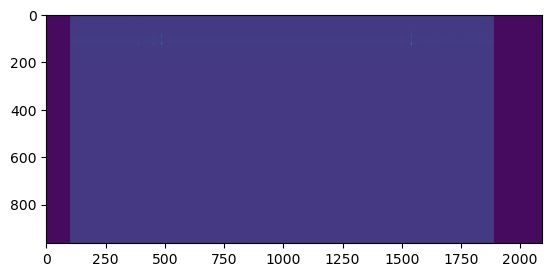

In [23]:
plt.imshow(image)

In [24]:
image_cut = image[60:160, 90:1890]

Text(0.5, 0, 'wavelenght')

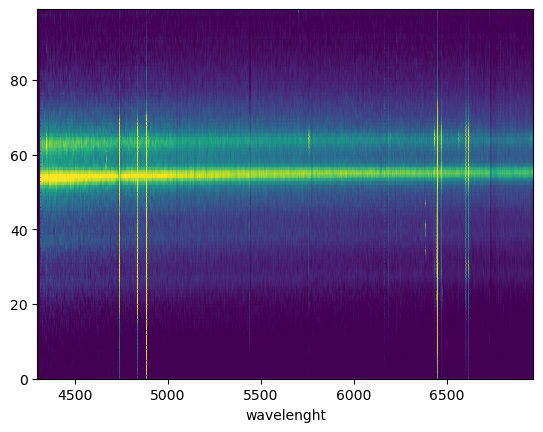

In [25]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')
#plt.axhline(58, color='red')

We know that redshift and wavelenghts are related in this way:
$\lambda_{obs} = \lambda_{em}*(1+z)$ \
So if we want:
- $\lambda_{obs}(H\alpha)$ = 6563 * (1+0.00323) = 6584 AA
- $\lambda_{obs}(H\beta)$ = 4861 * (1+0.00323) = 4877 AA
- $\lambda_{obs}([NII])$ = 6548 * (1+0.00323) = 6569 AA
- $\lambda_{obs}([SII])$ = 6717 * (1+0.00323) = 6739 AA
- $\lambda_{obs}([OIII])$ = 4959 * (1+0.00323) = 4975 AA


## Continuum 6500 AA

Text(0.5, 1.0, 'Continuum 6500 A')

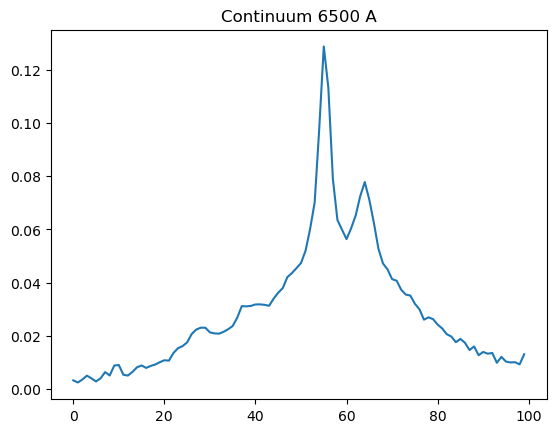

In [26]:
mask = (wavelenghts > 6490)*(wavelenghts < 6510)
image_6500 = image_cut[:, mask] #cut su 6500 A
radial_profile = np.mean(image_6500, axis = 1)
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile)
plt.title('Continuum 6500 A')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

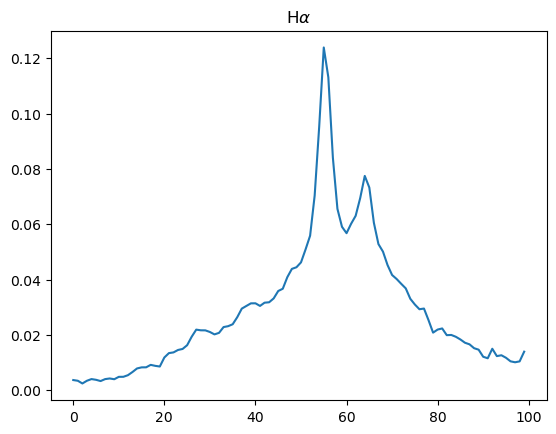

In [27]:
mask_HA = (wavelenghts > 6574)*(wavelenghts < 6594)
image_HA = image_cut[:, mask_HA]
radial_profile_HA = np.mean(image_HA, axis = 1)
plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')

The fit gives us these parameters: A = 0.11, A2 = 0.06, mu = 55.31, mu2 = 63.97, As = 0.02, r_eff = 66.13, n = 0.07


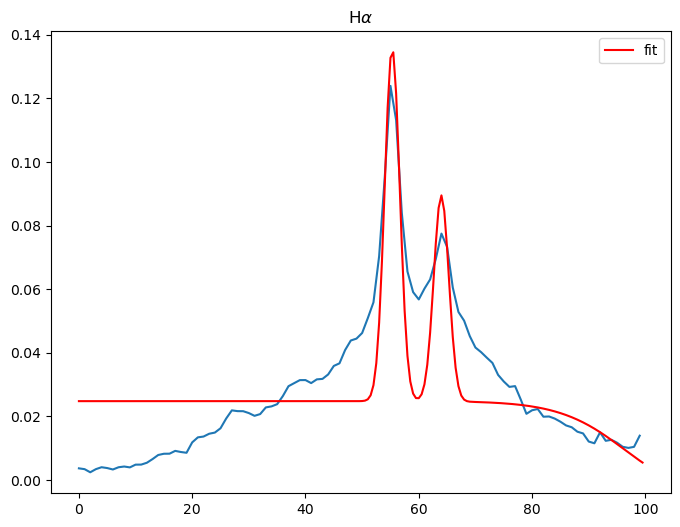

In [28]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_HA, p0=[0.12, 0.08, 50, 70, 1, 50, 1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()

plt.show()

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

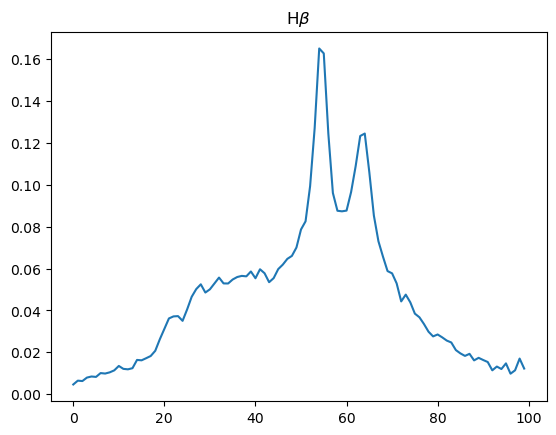

In [29]:
mask_HB = (wavelenghts > 4867)*(wavelenghts < 4887)
image_HB = image_cut[:, mask_HB] 
radial_profile_HB = np.mean(image_HB, axis = 1)
plt.plot(x_axes, radial_profile_HB)
plt.title(r'H$\beta$')

The fit gives us these parameters: A = 0.14, A2 = 0.10, mu = 54.46, mu2 = 63.35, As = 0.04, r_eff = 61.55, n = 0.09


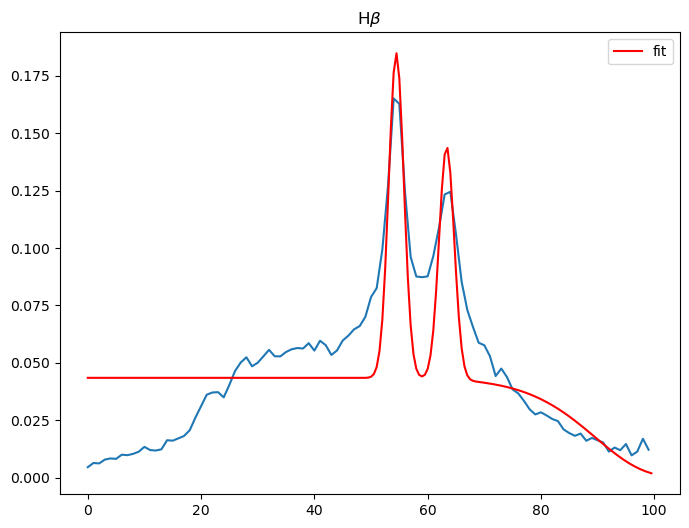

In [30]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_HB, p0=[0.16, 0.15, 50, 70, 1, 50, 1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_HB)
plt.title(r'H$\beta$')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()

## [NII]

Text(0.5, 1.0, '[NII]')

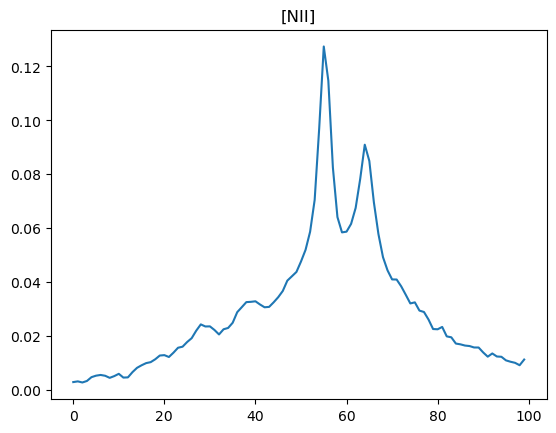

In [31]:
mask_NII = (wavelenghts > 6559)*(wavelenghts < 6579)
image_NII = image_cut[:, mask_NII] 
radial_profile_NII = np.mean(image_NII, axis = 1)
plt.plot(x_axes, radial_profile_NII)
plt.title(r'[NII]')

The fit gives us these parameters: A = 0.11, A2 = 0.08, mu = 55.26, mu2 = 64.13, As = 0.03, r_eff = 65.62, n = 0.07


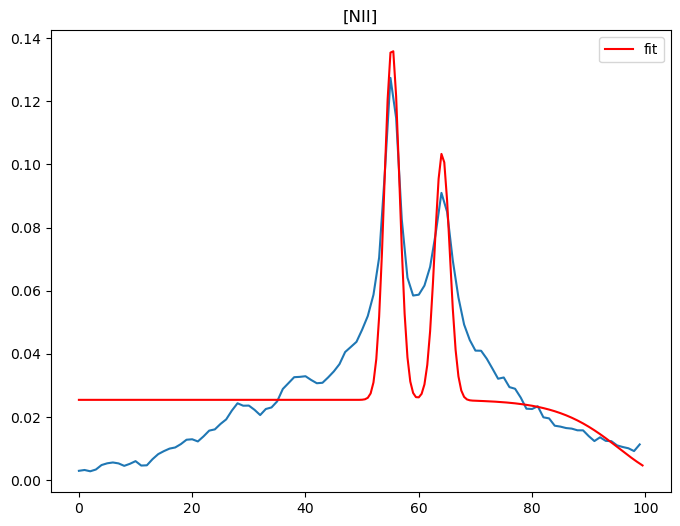

In [32]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_NII, p0=[0.12, 0.08, 50, 70, 1, 50, 1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_NII)
plt.title(r'[NII]')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()

## [SII]

Text(0.5, 1.0, '[SII]')

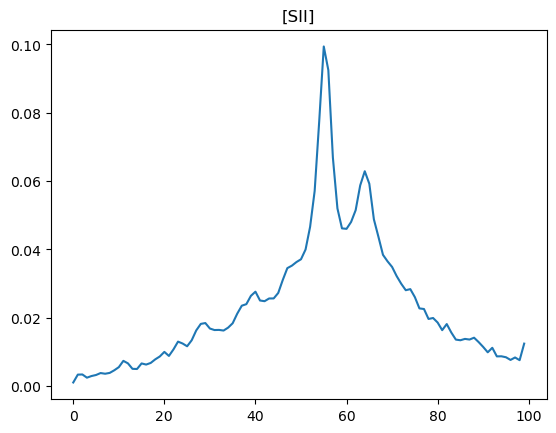

In [33]:
mask_SII = (wavelenghts > 6729)*(wavelenghts < 6749)
image_SII = image_cut[:, mask_SII]
radial_profile_SII = np.mean(image_SII, axis = 1)
plt.plot(x_axes, radial_profile_SII)
plt.title(r'[SII]')

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_11344\2782965712.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(model, x_axes, radial_profile_SII, p0=[0.1, 0.05, 50, 70, 1, 50, 1])


The fit gives us these parameters: A = 0.12, A2 = 0.08, mu = 55.29, mu2 = 63.88, As = 0.00, r_eff = 0.23, n = 0.38


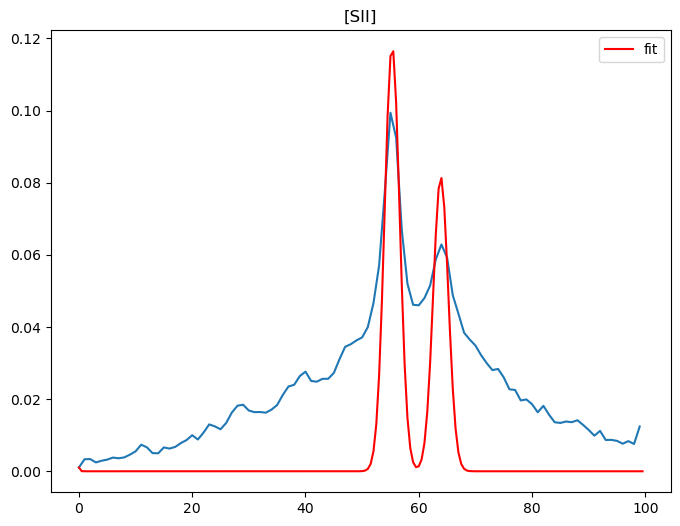

In [34]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_SII, p0=[0.1, 0.05, 50, 70, 1, 50, 1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_SII)
plt.title(r'[SII]')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()

## [OIII]

Text(0.5, 1.0, '[OIII]')

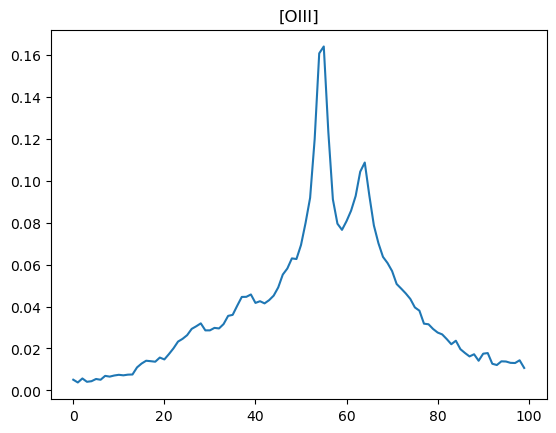

In [35]:
mask_OIII = (wavelenghts > 4965)*(wavelenghts < 4985)
image_OIII = image_cut[:, mask_OIII] 
radial_profile_OIII = np.mean(image_OIII, axis = 1)
plt.plot(x_axes, radial_profile_OIII)
plt.title(r'[OIII]')

The fit gives us these parameters: A = 0.15, A2 = 0.09, mu = 54.54, mu2 = 63.45, As = 0.03, r_eff = 64.07, n = 0.08


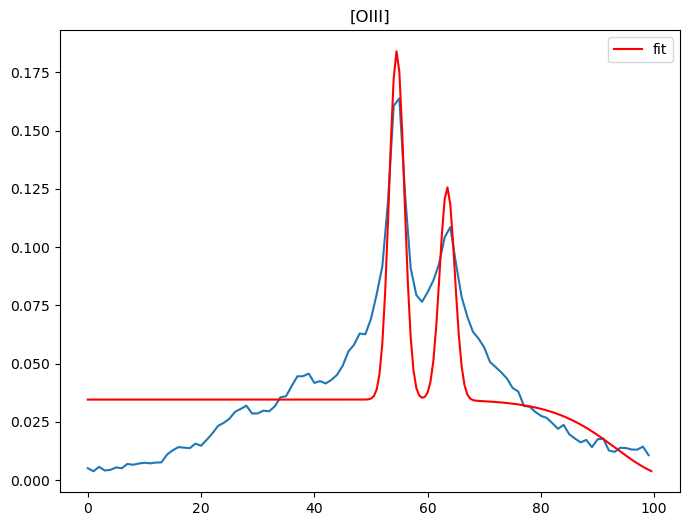

In [36]:
# FWHM = 2*sqrt(2*ln(2))*sigma ≈ 2.35482*sigma
sigma = 3.125/2.35

def model(x, A, A2, mu, mu2, As, r_eff, n):
    gauss1 = models.Gaussian1D(amplitude= A, mean=mu, stddev= sigma)(x)
    gauss2 = models.Gaussian1D(amplitude=A2, mean=mu2, stddev= sigma)(x)
    sersic = models.Sersic1D(amplitude=As, r_eff=r_eff, n=n)(x)
    return gauss1+gauss2+sersic
    
params, covariance = curve_fit(model, x_axes, radial_profile_OIII, p0=[0.15, 0.12, 50, 70, 1, 50, 1])
A, A2, mu, mu2, As, r_eff, n = params
print(r'The fit gives us these parameters: A = %.2f, A2 = %.2f, mu = %.2f, mu2 = %.2f, As = %.2f, r_eff = %.2f, n = %.2f' % (A, A2, mu, mu2, As, r_eff, n))
xgrid = np.arange(0, 100, 0.5)
y_fit = model(xgrid, *params)

plt.figure(figsize=(8, 6))

plt.plot(x_axes, radial_profile_OIII)
plt.title(r'[OIII]')
plt.plot(xgrid, y_fit, color = 'red', lw = 1.5, label ='fit')
plt.legend()
plt.show()